# Forecast Evolution Analysis (v2)
This notebook allows the user to interactively plot the "Linus plot" showing forecast evolution for a specific validity date. Tested on *IFS CF*, *AIFS Single*, *IFS ENS* and *AIFS CRPS-ENS* forecasts.

## User Configuration Options

- **Parameter**: Select from dropdown list
- **Forecast Settings**: 
  - Validity date (calendar picker)
  - Validity time (dropdown)
  - Step interval (dropdown)
  - Maximum forecast days (slider)
- **Model Selection**:
  - **Predefined models**: Select from the list of known models (IFS Control, AIFS Single, etc.)
  - **Custom MARS models**: Define your own model by specifying MARS retrieval arguments (`class`, `type`, `stream`, `expver`) plus optional extra keys (`model`, `database`, `grid`, ...)
- **Geographic Area**: Select using the interactive map

### Model Selection Methods

#### Predefined Models
Select one or more models from the list on the left. These have pre-configured MARS retrieval settings and plot styles.

#### Custom MARS Models
Use the panel on the right to add a model by specifying its MARS retrieval arguments:
- **Name**: A display name for the model
- **class**: MARS class (e.g. `od`, `ai`, `rd`, `d1`)
- **type**: Forecast type (`fc`, `cf`, `pf`)
- **stream**: Data stream (`oper`, `enfo`, ...)
- **expver**: Experiment version (optional)
- **Ensemble**: Tick if this is an ensemble (perturbed) forecast
- **Extra MARS arguments**: Add any additional key-value pairs (e.g. `model=aifs-single`, `database=...`, `grid=[0.25,0.25]`)

### Area Selection Methods

#### Polygon Selection
When drawing a polygon, the system creates a bounding box using the northernmost, westernmost, southernmost, and easternmost points of your selection.

#### Point Selection
When selecting a single point, the system creates a ±0.5° box around that location.

In [11]:
import os
import sys

# Ensure the package is importable
sys.path.insert(0, os.path.dirname(os.path.abspath("")))

base_path = os.path.join(os.path.dirname(os.path.abspath("")), "data_files")

from diag_evo import (
    setup_interface,
    retrieve_and_store_data,
    plot_forecast_evolution,
    plot_forecast_evolution_static,
    setup_data_directories,
    get_area_string,
)

# Set up the interface and get the widgets dictionary
widgets_dict = setup_interface()

Please configure your forecast settings:


In [3]:
# Optional: override configuration programmatically
ar=[51.39199, 5.69572, 50.11316, 9.43167]
#po= [50.881878, 7.013875]
widgets_dict['config']['area_sub'] = ar
#widgets_dict['config']['point'] = po


In [3]:
# Optional: override configuration programmatically
#widgets_dict['config']['area_sub'] = [63.76772, 12.62371, 62.76772, 13.62371]
#widgets_dict['config']['point'] = [63.26772, 13.123712]
#widgets_dict['config']['max_days'] = 4
#widgets_dict['config']['step_interval'] = 12

In [ ]:
# Optional: add custom models programmatically instead of using the UI
# from diag_evo import register_custom_model
# register_custom_model(
#     name='My Experiment',
#     retrieval_args={
#         'class': 'rd',
#         'type': 'fc',
#         'stream': 'oper',
#         'expver': 'xxxx',
#         'model': 'some-model',
#     },
#     is_ensemble=False,
#     color='#ff6600'
# )

In [12]:
plot_data = retrieve_and_store_data(widgets_dict, base_path)

Retrieving observations...
Retrieving new observation data...
Nearest station (stnid: 33000887, elevation: 47.0,lat: 50.57, lon: 3.0975, distance: 11.58 km, value: 87.50): stnid                   33000887
latitude                   50.57
longitude                 3.0975
level                        0.0
date         2026-02-15 12:00:00
elevation                   47.0
value_0                     87.5
distance               11.576172
Name: 1585, dtype: object
OBS value: 87.50
Station ID: 33000887
Station elevation: 47.0 m
Station latitude: 50.57°
Station longitude: 3.0975°
Retrieving analysis...
Retrieving analysis from MARS...
mars - WARN - 
mars - WARN - 
MIR environment variables:
MIR_CACHE_PATH={FILE?/ec/cache.1}/cache:{FILE?/ec/cache.2}/cache
MIR_LSM_NAMED=1km.climate.v013
Using MARS binary: /usr/local/apps/mars/versions/6.33.26.4/bin/mars.bin
mars - INFO   - 20260222.230451 - Welcome to MARS
mars - INFO   - 20260222.230451 - MARS_HOME=/usr/local/apps/mars/configs/prod
mars - INFO  

/etc/ecmwf/nfs/dh1_perm_a/ecm3468/for_Balazs/diag_evo_v2/diag_evo/core.py:1337: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [ ]:
from diag_evo import get_model_plot_settings

# Build a color map for all selected models
color_map = {}
for model_name in widgets_dict['model_widgets'].value:
    plot_cfg = get_model_plot_settings(model_name)
    color_map[model_name] = plot_cfg['color']

widgets_dict['config']['model_colors'] = color_map

In [5]:
widgets_dict['config']['model_colors']['AIFS ENS Control']="#00FF1E"

In [6]:
widgets_dict['config']['model_colors']={'IFS Control': "#dd00ff",
 'AIFS Single': "#93190c",
 'AIFS ENS Control': '#00FF1E',
 'IFS ENS': "#08fff7",
 'AIFS CRPS-ENS': "#2c32a0"}

Plot exported to: /etc/ecmwf/nfs/dh1_perm_a/ecm3468/for_Balazs/data_files/tcc_N51.15817_W2.51025_S50.15817_E3.51025_20260215/plot_files/forecast_evolution_point_50.6582N_3.0103E_20260215_1200_tcc.html


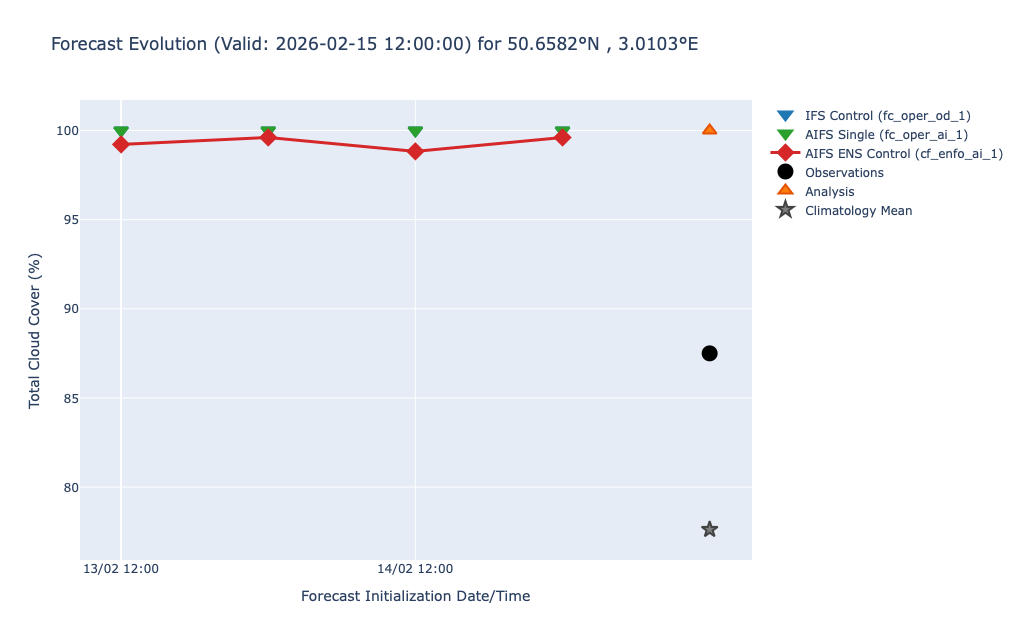

In [13]:
area_str = get_area_string(widgets_dict['config']['area_sub'])
date_str = widgets_dict['config']['valid_date'].strftime("%Y%m%d")
_, _, plot_dir = setup_data_directories(base_path, widgets_dict['config']['param'], area_str, date_str)
plot_data['data_df'].to_csv(f'{plot_dir}/plot_data.csv', index=False)

# Create the interactive plot
plot_forecast_evolution(plot_data, widgets_dict, plot_dir, export_html=True)

Static plot exported to: /etc/ecmwf/nfs/dh1_perm_a/ecm3468/for_Balazs/data_files/tcc_N51.15817_W2.51025_S50.15817_E3.51025_20260215/plot_files/forecast_evolution_static_point_50.6582N_3.0103E_20260215_1200_tcc.png


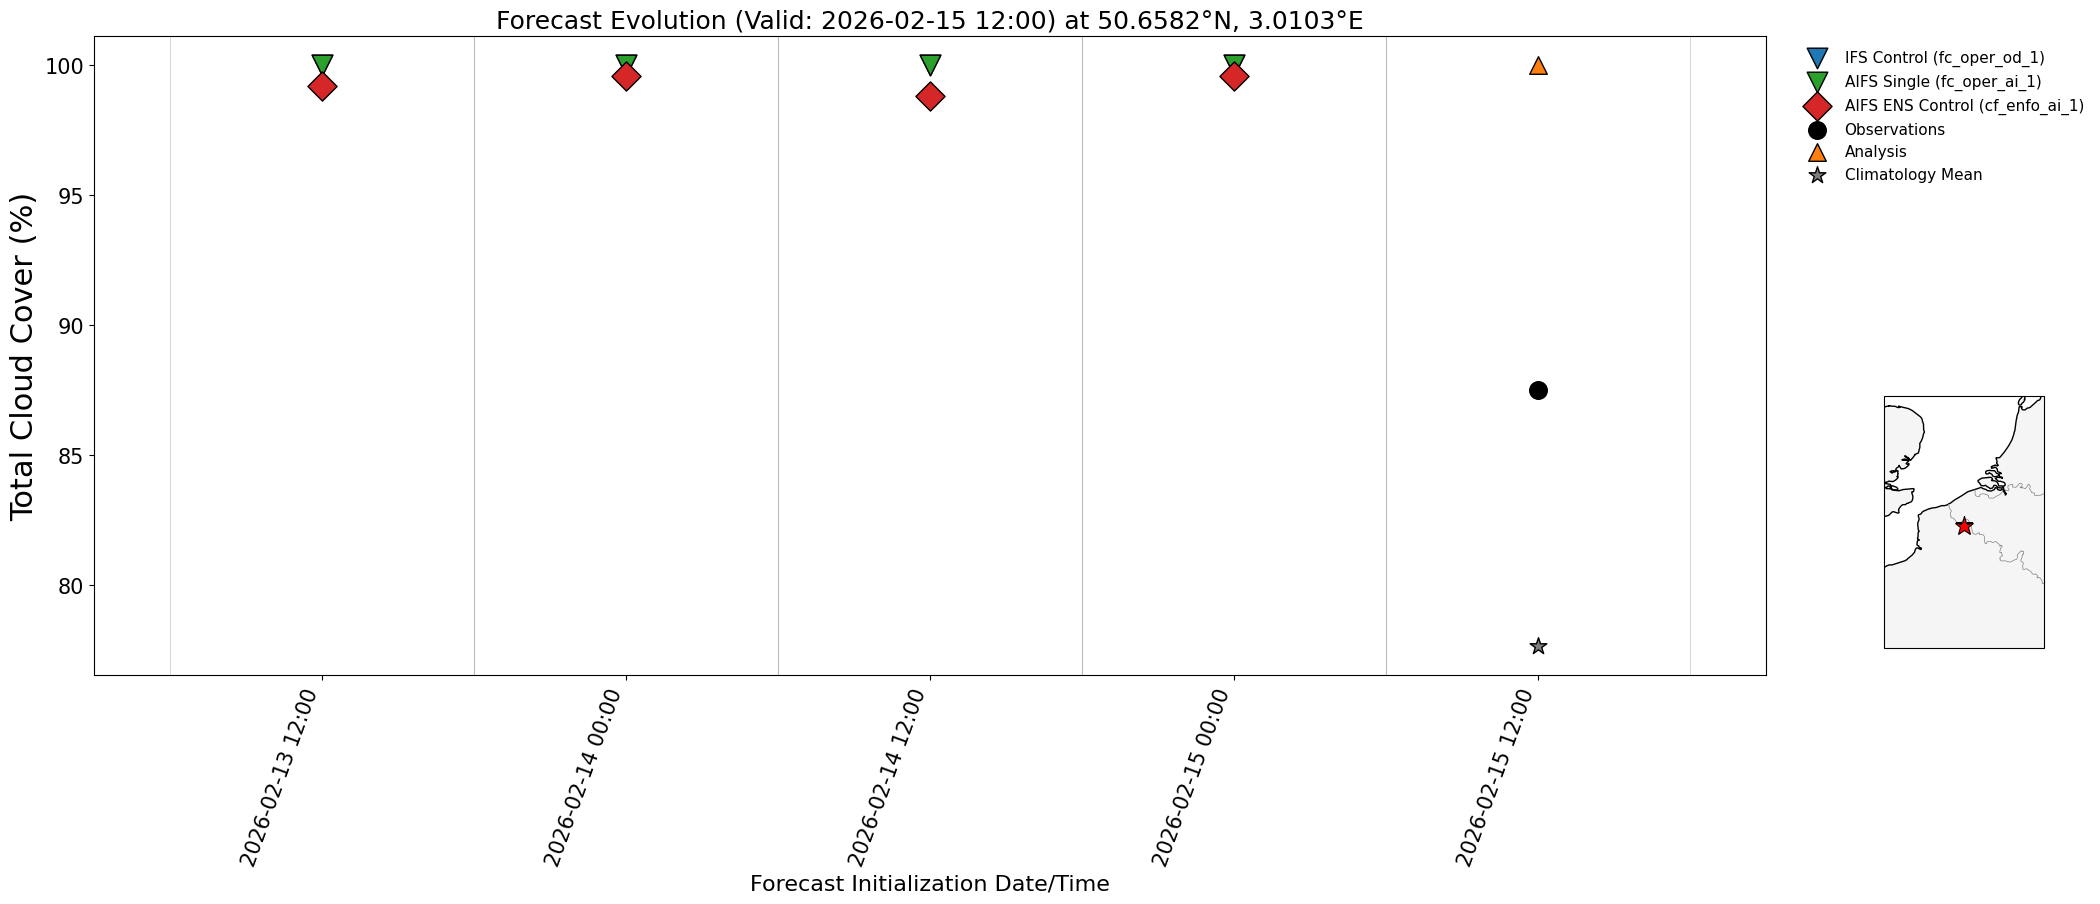

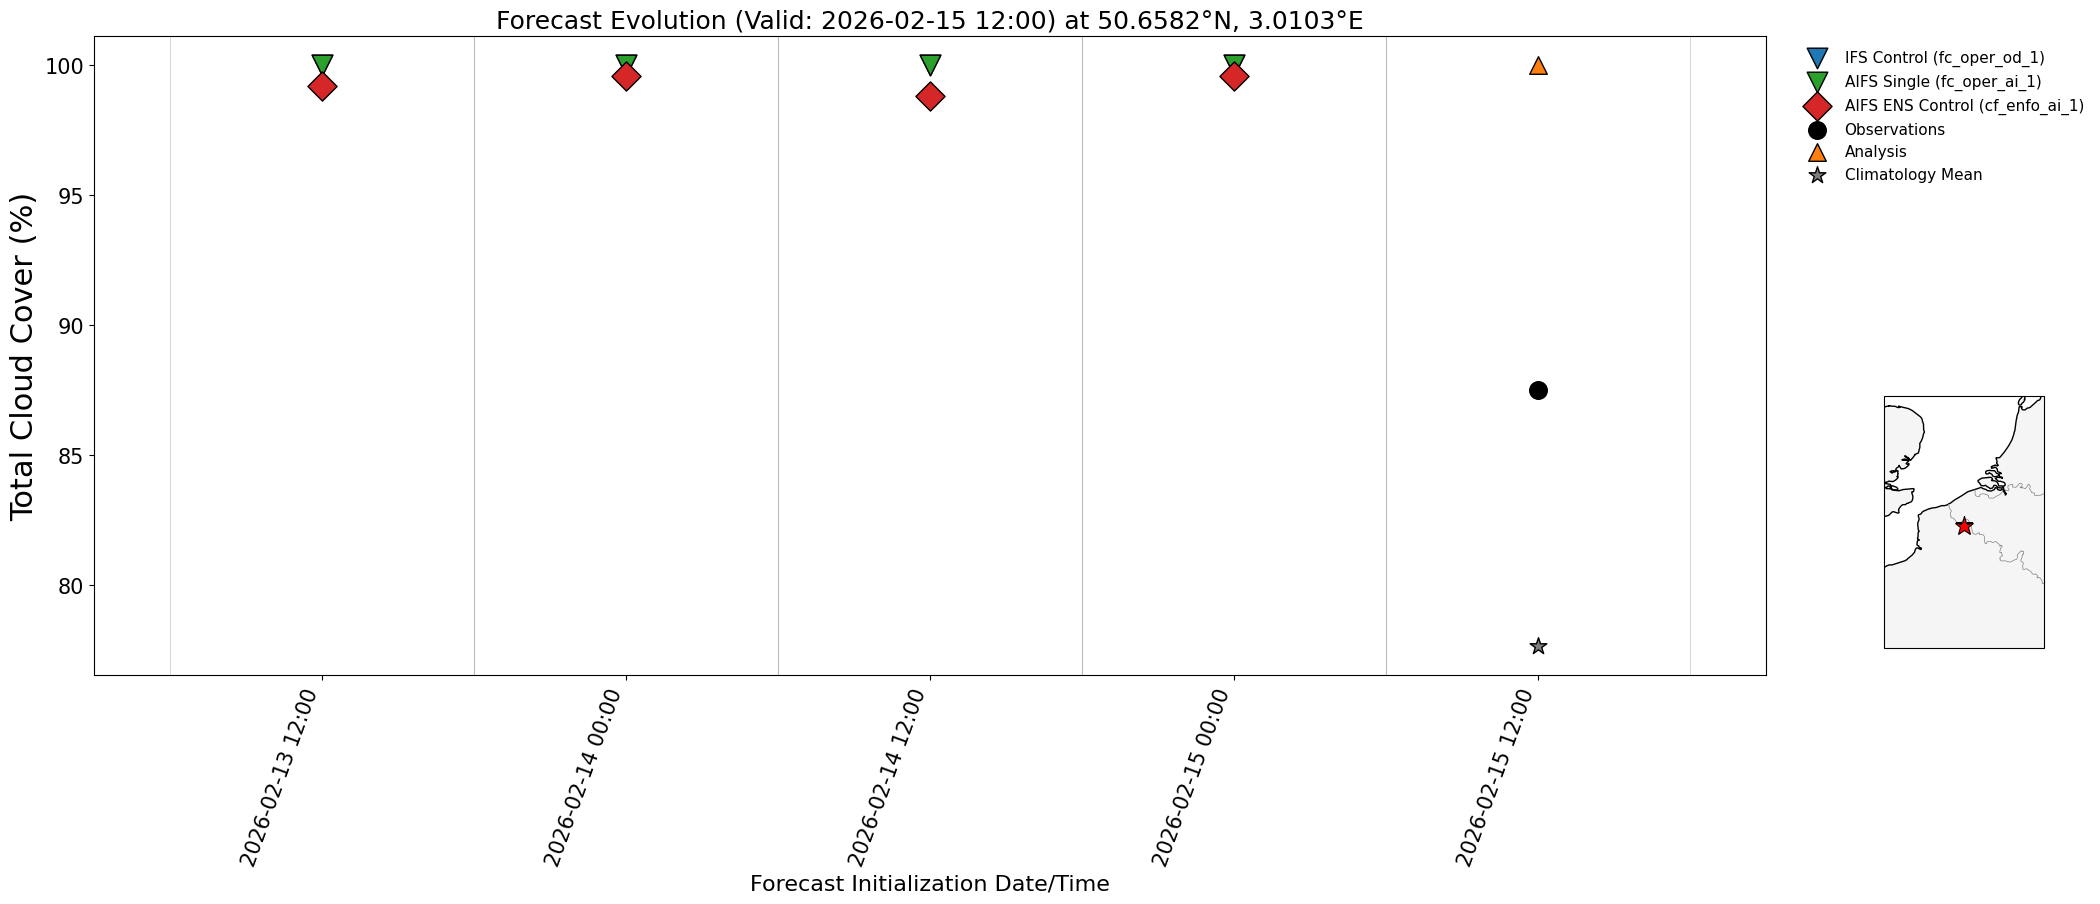

In [14]:
plot_forecast_evolution_static(plot_data, widgets_dict, plot_dir, export_png=True)

# diag_evo — Forecast Evolution Diagnostics

Interactive and static visualisation of forecast evolution ("Linus plot")
for multiple NWP and ML models.  Built on **MARS**, **earthkit-data**,
**Metview**, **ipywidgets** and **Plotly / Matplotlib**.

![example static plot](docs/example_static.png)

---

## Features

| Feature | Details |
|---------|---------|
| **Predefined models** | IFS Control, AIFS Single, AIFS ENS Control, IFS ENS, AIFS CRPS-ENS, DE-LUMI, DE-ATOS |
| **Custom MARS models** | Add any model at runtime by specifying `class`, `type`, `stream`, `expver` and optional extra MARS keys |
| **Interactive plot** | Plotly box-plots with hover info (bias, lead time, member index) |
| **Static plot** | Matplotlib percentile boxes (1/10/25/50/75/90/99) with inset map |
| **Reference data** | Analysis, ERA5 climatology, observations |
| **Accumulated variables** | Automatic step differencing with configurable accumulation period |
| **Colour overrides** | Per-model colour control via `widgets_dict['config']['model_colors']` |
| **Export** | HTML (interactive) and PNG (static) |

---

## Repository layout

```
diag_evo_v2/
├── diag_evo/                  # Python package
│   ├── __init__.py            # Public API
│   ├── core.py                # UI, retrieval and plotting logic
│   ├── settings.py            # Model & plot settings helpers
│   ├── variables.py           # Variable metadata & unit conversion
│   └── config/                # Default JSON configuration
│       ├── model_settings.json
│       ├── plot_settings.json
│       └── variable_settings.json
├── examples/
│   └── forecast_evolution.ipynb   # Ready-to-run example notebook
├── data_files/                # Auto-created at runtime (.gitignored)
├── requirements.txt
├── .gitignore
└── README.md                  # ← you are here
```

---

## Installation

The package is designed to run on systems where **Metview** and
**earthkit-data** are already available (e.g. ECMWF workstations / Atos
HPC).  Clone the repository and install the remaining Python
dependencies:

```bash
git clone <repo-url> diag_evo_v2
cd diag_evo_v2
pip install -r requirements.txt
```

No `pip install -e .` step is needed — just make sure `diag_evo_v2/` is
on your `PYTHONPATH` or run notebooks from within the repository.

> **Tip:** On ECMWF systems, activate the standard environment first
> (`module load python3`, etc.) so that `metview` and `earthkit.data`
> are available.

---

## Quick start

```python
import sys, os
sys.path.insert(0, "/path/to/diag_evo_v2")

from diag_evo import (
    setup_interface,
    retrieve_and_store_data,
    plot_forecast_evolution,
    plot_forecast_evolution_static,
    setup_data_directories,
    get_area_string,
)

# 1. Launch the interactive widget UI
widgets_dict = setup_interface()

# 2. (Optional) override settings programmatically
# widgets_dict['config']['area_sub'] = [51.4, 5.7, 50.1, 9.4]
# widgets_dict['config']['point'] = [50.88, 7.01]

# 3. Retrieve data
base_path = "data_files"
plot_data = retrieve_and_store_data(widgets_dict, base_path)

# 4. Build output directories
area_str = get_area_string(widgets_dict['config']['area_sub'])
date_str = widgets_dict['config']['valid_date'].strftime("%Y%m%d")
_, _, plot_dir = setup_data_directories(base_path, widgets_dict['config']['param'], area_str, date_str)

# 5. Plot
plot_forecast_evolution(plot_data, widgets_dict, plot_dir, export_html=True)
plot_forecast_evolution_static(plot_data, widgets_dict, plot_dir, export_png=True)
```

See [`examples/forecast_evolution.ipynb`](examples/forecast_evolution.ipynb)
for a complete worked example.

---

## Adding custom models

### Via the UI

Use the **Custom MARS Model** panel on the right-hand side of the widget
interface.  Fill in `class`, `type`, `stream`, `expver`, tick
**Ensemble** if applicable, and click **Add Model**.

### Programmatically

```python
from diag_evo import register_custom_model

register_custom_model(
    name="My Experiment",
    retrieval_args={
        "class": "rd",
        "type": "fc",
        "stream": "oper",
        "expver": "xxxx",
    },
    is_ensemble=False,
    color="#ff6600",
)
```

---

## Colour overrides

Override plot colours for any model *before* calling the plot functions:

```python
widgets_dict['config']['model_colors'] = {
    'IFS Control': '#dd00ff',
    'AIFS CRPS-ENS': '#2c32a0',
}
```

---

## Configuration files

| File | Purpose |
|------|---------|
| `diag_evo/config/model_settings.json` | MARS retrieval arguments per model |
| `diag_evo/config/plot_settings.json` | Marker styles, colours, layout |
| `diag_evo/config/variable_settings.json` | Variable metadata, units, conversion rules |

Edit these to add new predefined models or variables without touching
Python code.

---

## Dependencies

See [`requirements.txt`](requirements.txt).  Key dependencies:

- Python ≥ 3.9
- `metview` (system install)
- `earthkit-data`
- `ipywidgets`, `ipyleaflet`
- `plotly`, `matplotlib`, `cartopy`
- `numpy`, `pandas`

---

## License

Internal use — ECMWF.
